In [ ]:
#Churn prediction in telecom.
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!gdown 1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m

Downloading...
From: https://drive.google.com/uc?id=1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m
To: /content/churn_logistic.csv
100% 494k/494k [00:00<00:00, 168MB/s]


In [ ]:
import pandas as pd
churn = pd.read_csv("churn_logistic.csv")
churn.head()

,Account Length,VMail Message,Day Mins,Eve Mins,Night Mins,Intl Mins,CustServ Calls,Intl Plan,VMail Plan,Day Calls,...,Eve Calls,Eve Charge,Night Calls,Night Charge,Intl Calls,Intl Charge,State,Area Code,Phone,Churn
0,128,25,265.1,197.4,244.7,10.0,1,0,1,110,...,99,16.78,91,11.01,3,2.70,KS,415,382-4657,0
1,107,26,161.6,195.5,254.4,13.7,1,0,1,123,...,103,16.62,103,11.45,3,3.70,OH,415,371-7191,0
2,137,0,243.4,121.2,162.6,12.2,0,0,0,114,...,110,10.30,104,7.32,5,3.29,NJ,415,358-1921,0
3,84,0,299.4,61.9,196.9,6.6,2,1,0,71,...,88,5.26,89,8.86,7,1.78,OH,408,375-9999,0
4,75,0,166.7,148.3,186.9,10.1,3,1,0,113,...,122,12.61,121,8.41,3,2.73,OK,415,330-6626,0


In [ ]:
churn["Churn"].value_counts()

,count
Churn,
0,2850
1,2850


<Axes: xlabel='Churn', ylabel='Day Mins'>

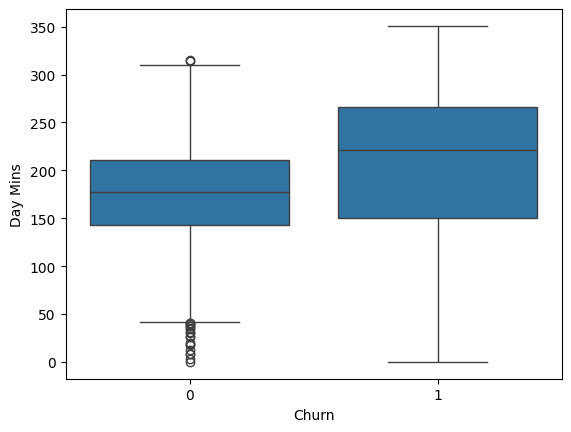

In [ ]:
import seaborn as sns
sns.boxplot(x='Churn', y='Day Mins', data = churn)

<Axes: xlabel='Churn', ylabel='Account Length'>

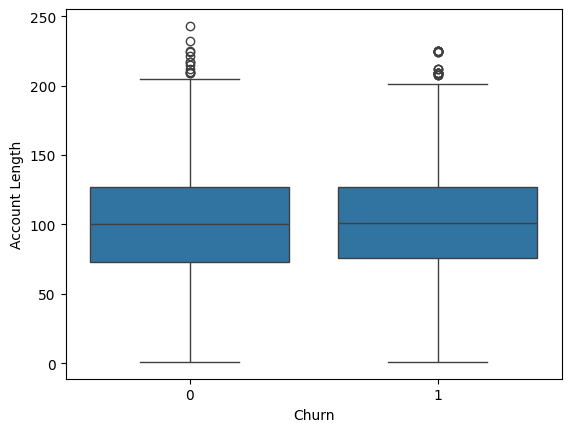

In [ ]:
sns.boxplot(x = 'Churn', y= 'Account Length', data = churn)

In [ ]:
cols = ['Day Mins', 'Eve Mins', 'CustServ Calls', 'Intl Plan','VMail Message']
y = churn["Churn"]
X = churn[cols]
X.shape

(5700, 5)

In [ ]:
from sklearn.model_selection import train_test_split

X_tr_cv, X_test, y_tr_cv, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_tr_cv, y_tr_cv, test_size=0.25,random_state=4)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [ ]:
X_train

array([[-1.3401872 , -2.29116555, -0.52179332,  2.19011647, -0.5352414 ],
       [-0.37273287, -1.19169576, -1.15081453, -0.45659672, -0.5352414 ],
       [ 1.54289097,  0.33984637, -0.52179332, -0.45659672, -0.5352414 ],
       ...,
       [ 0.83417443,  0.52694913, -1.15081453, -0.45659672, -0.5352414 ],
       [-0.58807985, -0.12887496,  1.3652703 , -0.45659672, -0.5352414 ],
       [-0.45469329,  1.42195611,  0.73624909,  2.19011647,  1.68255781]])

In [ ]:
#lr = LinearRegression()
#lr.fit(X,y)


from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
model.coef_

array([[ 0.78674301,  0.31084942,  0.94070165,  0.86919545, -0.31809071]])

In [ ]:
model.intercept_

array([0.05297365])

In [ ]:
X_val

array([[-0.74235828,  1.13840864, -0.52179332, -0.45659672, -0.5352414 ],
       [-1.80784369,  0.65039837, -0.52179332, -0.45659672, -0.5352414 ],
       [-0.14774349, -0.73069   ,  0.73624909, -0.45659672, -0.5352414 ],
       ...,
       [-1.49125149,  0.03122327, -1.15081453, -0.45659672,  1.30017864],
       [-1.21483597, -1.60640805, -1.15081453,  2.19011647, -0.5352414 ],
       [ 0.09492362, -0.90621939, -1.15081453, -0.45659672, -0.5352414 ]])

In [ ]:
y_pred=model.predict(X_val)
print(y_pred)

[0 0 1 ... 0 0 0]


In [ ]:
y_pred_prob=model.predict_proba(X_val)
print(y_pred_prob)

[[0.70985217 0.29014783]
 [0.8681417  0.1318583 ]
 [0.45621812 0.54378188]
 ...
 [0.95273524 0.04726476]
 [0.60128439 0.39871561]
 [0.81202669 0.18797331]]


In [ ]:
print(f'Train Accuracy:{model.score(X_train,y_train)}, Val Accuracy:{model.score(X_val,y_val) }' )

Train Accuracy:0.7564327485380117, Val Accuracy:0.7578947368421053


In [ ]:
model.predict -> sigmoid

model.fit -> log loss

In [ ]:
from sklearn.pipeline import make_pipeline
train_scores = []
val_scores = []
scaler = StandardScaler()
for la in np.arange(0.01, 12000.0, 100): # range of values of Lambda
  scaled_lr = make_pipeline( scaler, LogisticRegression(C=1/la))
  scaled_lr.fit(X_train, y_train)
  train_score = scaled_lr.score(X_train, y_train)
  val_score = scaled_lr.score(X_val, y_val)
  train_scores.append(train_score)
  val_scores.append(val_score)

In [ ]:
len(val_scores)

120

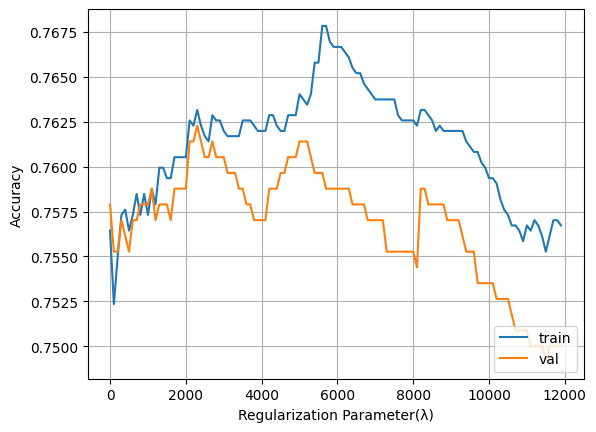

In [ ]:
plt.figure()
plt.plot(list(np.arange(0.01, 12000.0, 100)), train_scores, label="train")
plt.plot(list(np.arange(0.01, 12000.0, 100)), val_scores, label="val")
plt.legend(loc='lower right')

plt.xlabel("Regularization Parameter(λ)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [ ]:
when using λ = [1,0.1,0.01],
we got train and test accuracy as [0.90, 0.98, 0.93], [0.78,0.99,0.97]
What is the best λ ?

1. 1
2. 0.1
3. 0.01

In [ ]:
np.argmax(val_scores)

np.int64(23)

In [ ]:
val_scores[23]

0.762280701754386

In [ ]:
l_best = 0.01 * 23 * 100

In [ ]:
scaled_lr = make_pipeline( scaler, LogisticRegression(C=1/l_best))
scaled_lr.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.043478260869565216))])

In [ ]:
test_score = scaled_lr.score(X_test,y_test)
print(test_score)

0.7657894736842106


In [ ]:
#break : 10 32

In [ ]:
from scipy.linalg.lapack import regex_compile
Default - L2 regularisation
LogisticRegression(C= 1/la, l1_ratio = 0.5)
0 -> L2 regularisation
1 -> L1 regularisation
Elastic Reg -> 0 to 1
0.5

In [ ]:
For three models, the yhat values come to be:
M1=0.34
M2=0.28
M3=0.35

What would be the predicted output class by the classifier?

a. M1
b. M2
c. M3
d. None since no model has yhat>0.5

log = LogisticRegression(multi_class = 'ovr')